**Assignment 4: Training a DCGAN on the Fashion-MNIST Dataset**

Step 1: Importing Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Step 2: Basic Parameter

All hyperparameters are hardcoded here including the noise vector size.



In [ ]:
batch_size = 64
image_size = 28
noise_size = 100
epochs = 25
learning_rate = 0.0002

Step 3: Load Fashion-MNIST Dataset

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 119MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.42MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 46.3MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.9MB/s]


Step 4: Display Original Images

Display real Fashion-MNIST images to verify that the dataset is loaded correctly.



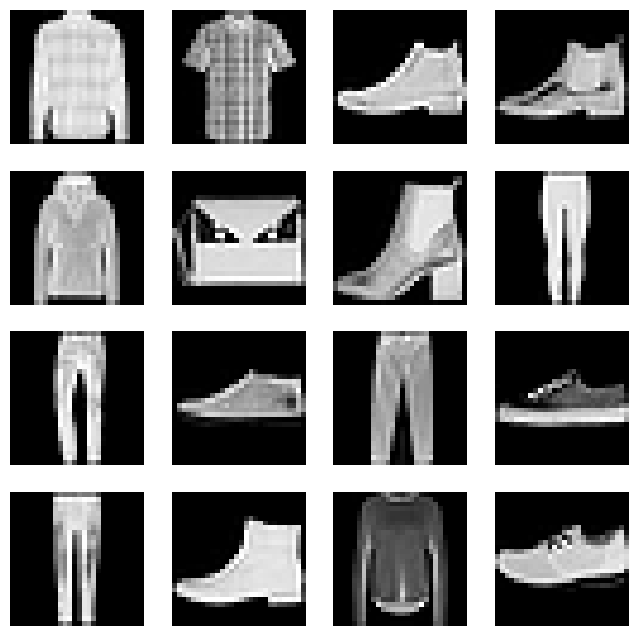

In [ ]:
images, labels = next(iter(dataloader))

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

Step 5: Build the Generator

Build a generator that converts random noise into a 28×28 image using transposed convolution layers.

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.ConvTranspose2d(100, 128, 7, 1, 0),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

generator = Generator()

Step 6: Test the Generator

Generate images before training to observe the initial random output.

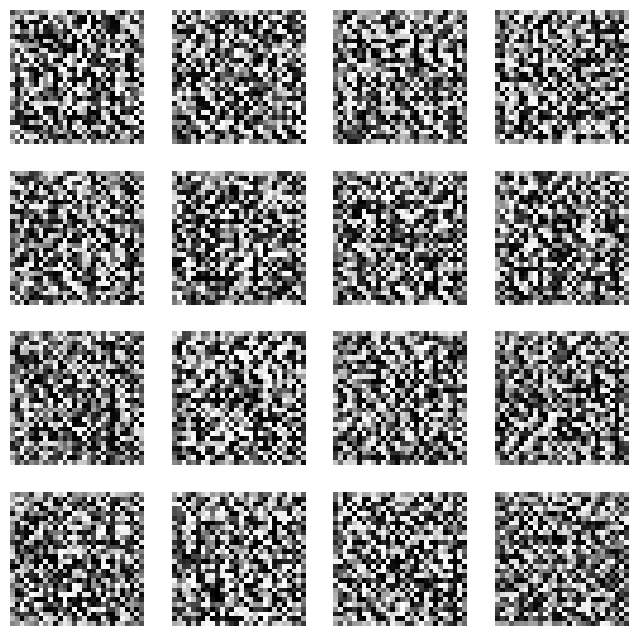

In [ ]:
noise = torch.randn(16, 100, 1, 1)

fake_images = generator(noise)

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(fake_images[i].detach().squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

tep 7: Build the Discriminator

Build a discriminator using convolution layers to classify images as real or fake.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

discriminator = Discriminator()


Step 8: Define Loss and Optimizers

Define Binary Cross Entropy loss and Adam optimizers for training both networks

In [ ]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=learning_rate,
    betas=(0.5, 0.999)
)

Step 9: Train the DCGAN

Train the discriminator and generator alternately and record their losses.

In [ ]:
G_losses = []
D_losses = []

In [ ]:
for epoch in range(25):

    for real_images, _ in dataloader:

        # -----------------
        # Train Discriminator
        # -----------------

        batch_size_now = real_images.size(0)

        real_labels = torch.ones(batch_size_now, 1)
        fake_labels = torch.zeros(batch_size_now, 1)

        # Real images
        output_real = discriminator(real_images)
        loss_real = criterion(output_real, real_labels)

        # Fake images
        noise = torch.randn(batch_size_now, 100, 1, 1)
        fake_images = generator(noise)

        output_fake = discriminator(fake_images.detach())
        loss_fake = criterion(output_fake, fake_labels)

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        optimizer_D.zero_grad()
        loss_D.backward()
        optimizer_D.step()


        # -----------------
        # Train Generator
        # -----------------

        noise = torch.randn(batch_size_now, 100, 1, 1)
        fake_images = generator(noise)

        output = discriminator(fake_images)

        loss_G = criterion(output, real_labels)

        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()


        # Save losses
        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())

    print(
        f"Epoch [{epoch+1}/25] "
        f"Generator Loss: {loss_G.item():.4f} "
        f"Discriminator Loss: {loss_D.item():.4f}"
    )

Epoch [1/25] Generator Loss: 1.1131 Discriminator Loss: 0.9227
Epoch [2/25] Generator Loss: 1.4181 Discriminator Loss: 1.1545
Epoch [3/25] Generator Loss: 1.6664 Discriminator Loss: 1.0340
Epoch [4/25] Generator Loss: 1.1951 Discriminator Loss: 0.8892
Epoch [5/25] Generator Loss: 1.6342 Discriminator Loss: 1.0563
Epoch [6/25] Generator Loss: 1.8362 Discriminator Loss: 1.0521
Epoch [7/25] Generator Loss: 1.6441 Discriminator Loss: 0.8049
Epoch [8/25] Generator Loss: 0.9478 Discriminator Loss: 0.9120
Epoch [9/25] Generator Loss: 1.2379 Discriminator Loss: 0.8604
Epoch [10/25] Generator Loss: 0.8288 Discriminator Loss: 1.0162
Epoch [11/25] Generator Loss: 1.3881 Discriminator Loss: 1.0669
Epoch [12/25] Generator Loss: 0.9969 Discriminator Loss: 0.9546
Epoch [13/25] Generator Loss: 1.2757 Discriminator Loss: 1.1667
Epoch [14/25] Generator Loss: 1.4670 Discriminator Loss: 0.7476
Epoch [15/25] Generator Loss: 0.9968 Discriminator Loss: 1.1978
Epoch [16/25] Generator Loss: 1.7894 Discriminato

Step 10: Save Generated Images

Save a 4×4 grid of generated images every 5 epochs to observe how the images improve during training.

In [ ]:
fixed_noise = torch.randn(16, 100, 1, 1)

for epoch in range(25):

    # Training code goes here

    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            fake_images = generator(fixed_noise)

        plt.figure(figsize=(8, 8))

        for i in range(16):
            plt.subplot(4, 4, i + 1)
            plt.imshow(fake_images[i].squeeze(), cmap="gray")
            plt.axis("off")

        plt.suptitle(f"Generated Images - Epoch {epoch + 1}")
        plt.show()

Step 11: Plot Losses

Plot the Generator and Discriminator losses to understand how the two networks learn during training.


In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Generator and Discriminator Loss")
plt.legend()

plt.show()

Step 12: Observation and Conclusion

1. How do images change from Epoch 5 to Epoch 25?

At Epoch 5, the generated images are still somewhat noisy and unclear. As training continues, the clothing shapes become clearer and more recognizable. By Epoch 25, the images are more defined compared with the early epochs.

2. Can you observe instability in training?

The Generator and Discriminator losses change throughout training instead of remaining constant. This shows that both networks are competing with each other. Some variation in the losses is normal in GAN training.

3. At which epoch do clothing-like shapes become recognizable?

Clothing-like shapes start becoming recognizable around Epoch 10–15. The exact epoch can be identified by comparing the generated image grids.

4. Does the image quality continue improving?

The image quality improves during the initial training stages. After some epochs, the improvement may become smaller, indicating that the Generator has reached a point where further training gives limited improvement.

5. Is there mode collapse?

Check whether many generated images look almost identical. If the images are different and represent different clothing shapes, there is no obvious mode collapse.

